| Name | Student ID |
| :--- | :--- |
| **Tran Anh Chuong** | V202401566 |
| **Duong Hien Chi Kien** | V202401461 |


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

## 🔹 Part 1️ Data Cleaning & Exploration
💡 Objective: Prepare and clean the dataset before analysis.

### **Q1. Choose one dataset (CO₂, COVID, or Temperature) and clean it by:**
-	🧹 Removing all rows with missing values for key columns.
-	Filtering only data before 2023 (to avoid incomplete data).
-	Keeping only relevant columns that will be useful for analysis.

### **Q2. Display basic summary statistics using .describe().y**
- 🔍 What are the minimum, maximum, and average values for key numerical columns?
-	Check for missing values using .isna().sum() and confirm they were removed.


In [3]:
df_covid = pd.read_csv('owid-covid-data.csv')
df_covid.head()

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
0,AFG,Asia,Afghanistan,2020-01-05,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772,NaN,NaN,NaN,NaN
1,AFG,Asia,Afghanistan,2020-01-06,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772,NaN,NaN,NaN,NaN
2,AFG,Asia,Afghanistan,2020-01-07,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772,NaN,NaN,NaN,NaN
3,AFG,Asia,Afghanistan,2020-01-08,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772,NaN,NaN,NaN,NaN
4,AFG,Asia,Afghanistan,2020-01-09,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772,NaN,NaN,NaN,NaN


In [4]:
df_covid.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 429435 entries, 0 to 429434
Data columns (total 67 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   iso_code                                    429435 non-null  object 
 1   continent                                   402910 non-null  object 
 2   location                                    429435 non-null  object 
 3   date                                        429435 non-null  object 
 4   total_cases                                 411804 non-null  float64
 5   new_cases                                   410159 non-null  float64
 6   new_cases_smoothed                          408929 non-null  float64
 7   total_deaths                                411804 non-null  float64
 8   new_deaths                                  410608 non-null  float64
 9   new_deaths_smoothed                         409378 non-null  float64
 

In [5]:
#Keep only the relevant columns for our analysis
#I chose these columns because they provide key information about the spread and impact of COVID-19, such as the location, date, total cases, new cases, total deaths, new deaths, and population. This will allow us to analyze trends and patterns in the data effectively.
relevant_features = ['location', 'date', 'total_cases', 'new_cases', 'total_deaths', 'new_deaths', 'population']
df_covid = df_covid[relevant_features]

# Convert 'date' to datetime format and extract 'year' for easier analysis
df_covid['date'] = pd.to_datetime(df_covid['date'])
df_covid['year'] = df_covid['date'].dt.year

# Filter data to only include years before 2023 (as requested by the rules)
df_covid = df_covid[df_covid['year'] < 2023]

In [6]:
df_covid.info()

<class 'pandas.core.frame.DataFrame'>
Index: 281002 entries, 0 to 428852
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   location      281002 non-null  object        
 1   date          281002 non-null  datetime64[ns]
 2   total_cases   268632 non-null  float64       
 3   new_cases     268622 non-null  float64       
 4   total_deaths  268632 non-null  float64       
 5   new_deaths    268626 non-null  float64       
 6   population    281002 non-null  int64         
 7   year          281002 non-null  int32         
dtypes: datetime64[ns](1), float64(4), int32(1), int64(1), object(1)
memory usage: 18.2+ MB


## 🔹 Part 2️ Aggregation & Filtering
💡 Objective: Extract meaningful insights from the dataset.

### **Q3. Identify the top 5 countries or regions based on a key metric:**
-	If working with CO₂ → Select the highest CO₂-emitting countries in 2021.
-	If working with Temperature → Find the countries with the highest average temperature before 2023.
-	If working with COVID → Find the 5 worst-affected countries in 2021 based on total cases or deaths.


### **Q4. Find the average value of a key metric per year using .groupby()**
-	If using CO₂, find the average CO₂ emissions per year.
-	If using Temperature, calculate yearly average temperatures.
-	If using COVID, find new cases per year.
-	📈 Display results as a DataFrame, showing the yearly trend.

In [7]:
df_2021 = df_covid[df_covid['year'] == 2021]    

# Group by location and find the highest total deaths recorded in 2021
top_5_deaths_2021 = df_2021.groupby('location')['total_deaths'].max().nlargest(5).reset_index()

print("Top 5 Countries by Total Deaths in 2021:")
print(top_5_deaths_2021)
print("\n")

Top 5 Countries by Total Deaths in 2021:
                        location  total_deaths
0                          World     5446878.0
1  Upper-middle-income countries     2330661.0
2          High-income countries     2029210.0
3                         Europe     1554407.0
4                           Asia     1251074.0




<Axes: xlabel='location'>

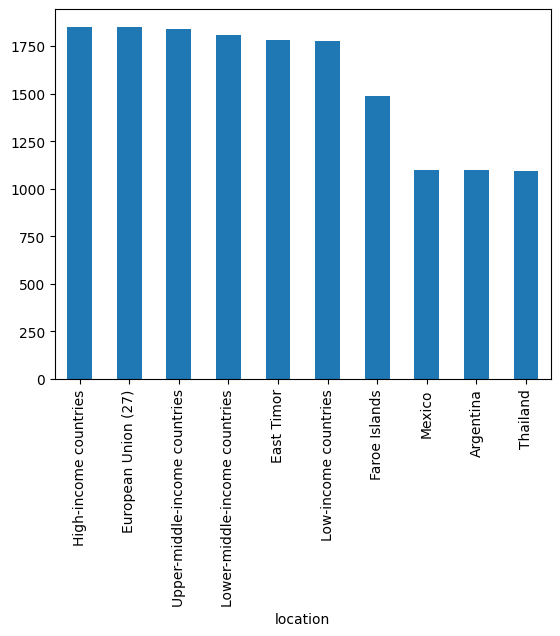

In [8]:
df_covid['location'].value_counts().head(10).plot(kind='bar')


In [9]:
df = pd.read_csv('owid-covid-data.csv')
df_check = df.loc[df['location'].isin(['High-income countries', 'Low-income countries', 'Upper-middle-income countries', 'European Union(27)']), ['location', 'date', 'continent']]
df_check

,location,date,continent
163847,High-income countries,2020-12-02,NaN
163848,High-income countries,2020-12-03,NaN
163849,High-income countries,2020-12-04,NaN
163850,High-income countries,2020-12-05,NaN
163851,High-income countries,2020-12-06,NaN
...,...,...,...
409807,Upper-middle-income countries,2024-07-31,NaN
409808,Upper-middle-income countries,2024-08-01,NaN
409809,Upper-middle-income countries,2024-08-02,NaN
409810,Upper-middle-income countries,2024-08-03,NaN


**From here I realized that there are some kind of "union" among countries that result in location name such as "Low-income countries", from here I decided to remake the assignment all over again as follows, I decided to filter out rows where it doesn't have continent value (continent = NaN)**

In [10]:
import pandas as pd

print("--- Q1: Data Cleaning & Feature Selection ---")
# Load the COVID-19 dataset
df = pd.read_csv('owid-covid-data.csv')

# 1. Feature Selection: Keep only the relevant columns 
# (Make sure to include 'continent' so we can use it for filtering!)
relevant_cols = [
    'iso_code',
    'continent', 'location', 'date', 
    'total_cases', 'new_cases', 'total_deaths', 'population'
]
df = df[relevant_cols]

# 2. FILTER OUT UNIONS/AGGREGATES: 
# Drop rows where 'continent' is NaN. This removes 'World', income groups, and entire continents.
df = df.dropna(subset=['continent'])

# 3. Filter data to only include years before 2023
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
final_df = df[df['year'] < 2023]

# 4. Remove all rows with missing values in our key metric columns
final_df = final_df.dropna(subset=['total_cases', 'new_cases', 'total_deaths'])

print("Data successfully cleaned (aggregates removed)! First 5 rows:")
print(final_df.head())
print("\n")

--- Q1: Data Cleaning & Feature Selection ---
Data successfully cleaned (aggregates removed)! First 5 rows:
  iso_code continent     location       date  total_cases  new_cases  \
0      AFG      Asia  Afghanistan 2020-01-05          0.0        0.0   
1      AFG      Asia  Afghanistan 2020-01-06          0.0        0.0   
2      AFG      Asia  Afghanistan 2020-01-07          0.0        0.0   
3      AFG      Asia  Afghanistan 2020-01-08          0.0        0.0   
4      AFG      Asia  Afghanistan 2020-01-09          0.0        0.0   

   total_deaths  population  year  
0           0.0    41128772  2020  
1           0.0    41128772  2020  
2           0.0    41128772  2020  
3           0.0    41128772  2020  
4           0.0    41128772  2020  




In [11]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)
stats = final_df[['total_cases', 'new_cases', 'total_deaths']].describe()
print("Summary Statistics:")
print(stats.loc[['min', 'max', 'mean']])

Summary Statistics:
      total_cases   new_cases  total_deaths
min          0.00        0.00          0.00
max   99019493.00 40475477.00    1079976.00
mean   1050286.93     2757.67      15466.80


In [12]:
print("\nMissing Values Count (Key columns should be 0):")
print(final_df.isna().sum())
print("\n")


Missing Values Count (Key columns should be 0):
iso_code        0
continent       0
location        0
date            0
total_cases     0
new_cases       0
total_deaths    0
population      0
year            0
dtype: int64




## 🔹 Part 2️ Aggregation & Filtering
💡 Objective: Extract meaningful insights from the dataset.

### **Q3. Identify the top 5 countries or regions based on a key metric:**
-	If working with CO₂ → Select the highest CO₂-emitting countries in 2021.
-	If working with Temperature → Find the countries with the highest average temperature before 2023.
-	If working with COVID → Find the 5 worst-affected countries in 2021 based on total cases or deaths.


### **Q4. Find the average value of a key metric per year using .groupby()**
-	If using CO₂, find the average CO₂ emissions per year.
-	If using Temperature, calculate yearly average temperatures.
-	If using COVID, find new cases per year.
-	📈 Display results as a DataFrame, showing the yearly trend.

In [13]:
df.head()

,iso_code,continent,location,date,total_cases,new_cases,total_deaths,population,year
0,AFG,Asia,Afghanistan,2020-01-05,0.00,0.00,0.00,41128772,2020
1,AFG,Asia,Afghanistan,2020-01-06,0.00,0.00,0.00,41128772,2020
2,AFG,Asia,Afghanistan,2020-01-07,0.00,0.00,0.00,41128772,2020
3,AFG,Asia,Afghanistan,2020-01-08,0.00,0.00,0.00,41128772,2020
4,AFG,Asia,Afghanistan,2020-01-09,0.00,0.00,0.00,41128772,2020


In [14]:
df_2021 = final_df[final_df['year'] == 2021]    

# Group by location and find the highest total deaths recorded in 2021
top_5_deaths_2021 = df_2021.groupby('location')['total_deaths'].max().nlargest(5).reset_index()

print("Top 5 Countries by Total Deaths in 2021:")
print(top_5_deaths_2021)
print("\n")

Top 5 Countries by Total Deaths in 2021:
        location  total_deaths
0  United States     812587.00
1         Brazil     618392.00
2          India     479682.00
3         Russia     304218.00
4         Mexico     303255.00




Yearly Average New Cases Trend (DataFrame):
   year  avg_new_cases
0  2020    80317671.00
1  2021   200298480.00
2  2022   424017377.00


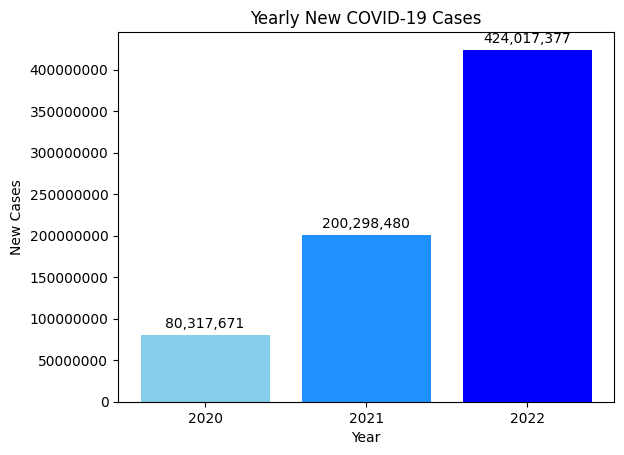

In [21]:
yearly_avg = final_df.groupby('year')['new_cases'].sum().reset_index()
# Rename columns for clarity in our DataFrame
yearly_avg.rename(columns={'new_cases': 'avg_new_cases'}, inplace=True)
print("Yearly Average New Cases Trend (DataFrame):")
print(yearly_avg)
# Define 3 distinct colors for the 3 years (2020, 2021, 2022)
bar_colors = ['skyblue', 'dodgerblue', 'blue']
# Create the bar chart and store it in a variable 'bars' so we can label it
bars = plt.bar(yearly_avg['year'], yearly_avg['avg_new_cases'], color=bar_colors)
plt.title('Yearly New COVID-19 Cases')
plt.xlabel('Year')
plt.ylabel('New Cases')
# Show plain numbers on the y-axis (disable scientific notation)
plt.ticklabel_format(style='plain', axis='y')
# Force the x-axis to only show the exact years present in the data
plt.xticks(yearly_avg['year'])
# Add the exact values on top of each bar, formatting them with commas
plt.bar_label(bars, labels=[f"{val:,.0f}" for val in yearly_avg['avg_new_cases']], padding=3)
plt.show()

## 🔹 Part 3: Advanced Data Processing

💡 Objective: Apply transformations and enhance the dataset.

### **Q5. Add a new column that shows percentage change in a key metric year-over-year**
-	Example: If using CO₂, calculate percentage change in CO₂ emissions per year.
-	Example: If using Temperature, calculate percentage change in average temperature per year.
-	Example: If using COVID, calculate percentage change in total cases per year.

💡 Hint: Use .pct_change() to compute the percentage difference between years.

### **Q6. Merge this dataset with another dataset (if applicable).**
-	Example: Merge CO₂ data with temperature data for the same country.
-	Example: Merge COVID data with population data (if the dataset contains population figures).
-	Ensure that the merged dataset only includes years with available data in both datasets.

In [16]:
# Let's calculate the total new cases recorded globally per year first
yearly_cases = final_df.groupby('year')['new_cases'].sum().reset_index()

# Add a new column to compute the year-over-year percentage change using .pct_change()
# We multiply by 100 to show it as a true percentage. 
# (Note: The first year, 2020, will show NaN because there is no prior year to compare to)
yearly_cases['pct_change'] = yearly_cases['new_cases'].pct_change() * 100

print("Global Total New Cases with Yearly Percentage Change:")
print(yearly_cases)
print("\n")

Global Total New Cases with Yearly Percentage Change:
   year    new_cases  pct_change
0  2020  80317671.00         NaN
1  2021 200298480.00      149.38
2  2022 424017377.00      111.69




In [17]:
# 1. Create a "Metrics" dataframe with our daily COVID stats
df_metrics = final_df[['location', 'date', 'year', 'total_cases', 'total_deaths']]

# 2. Create a separate "Population" dataframe 
# (We drop duplicates so we have one row per country)
df_pop = final_df[['location', 'population']].drop_duplicates()

# 3. Merge the metrics with the population data using an inner join on 'location'
merged_df = pd.merge(df_metrics, df_pop, on='location', how='inner')

print("Merged Dataset (Metrics & Population) - First 5 rows:")
print(merged_df.head())
print("\n")

Merged Dataset (Metrics & Population) - First 5 rows:
      location       date  year  total_cases  total_deaths  population
0  Afghanistan 2020-01-05  2020         0.00          0.00    41128772
1  Afghanistan 2020-01-06  2020         0.00          0.00    41128772
2  Afghanistan 2020-01-07  2020         0.00          0.00    41128772
3  Afghanistan 2020-01-08  2020         0.00          0.00    41128772
4  Afghanistan 2020-01-09  2020         0.00          0.00    41128772




### **Q7: Line Chart - Trend Over Time**
💡 Objective: Create a line chart showing how a key metric has changed over time.

-	🔍 Select a country or region and plot the trend of one metric (e.g., CO₂ emissions, temperature, COVID cases).
-	The x-axis should represent the year, and the y-axis should represent the chosen metric.
-	Add labels, a title, and a legend to make the chart meaningful.

Example Questions:

-	How have CO₂ emissions in the UK changed over the years?
-	How has the global average temperature fluctuated over time?
-	How did COVID cases in Vietnam evolve throughout 2021?

📌 Deliverable: A line chart showing the selected trend.

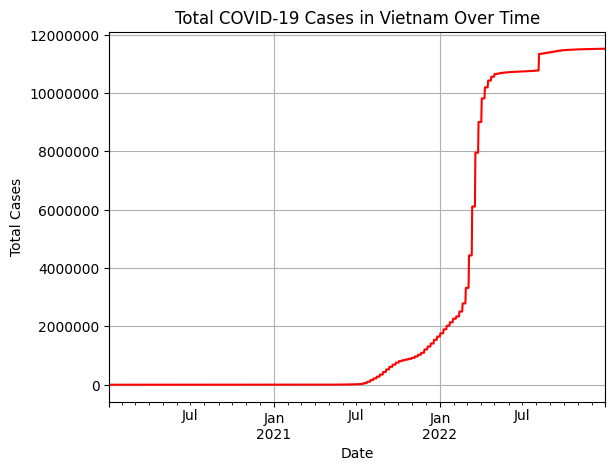

In [18]:
df_vietnam = final_df[final_df['location'] == 'Vietnam']

df_vietnam.plot(x='date', y='total_cases', kind='line', title='Total COVID-19 Cases in Vietnam Over Time', color='red', legend=False)
plt.xlabel('Date')
plt.ylabel('Total Cases')
plt.ticklabel_format(style='plain', axis='y')
plt.grid(True)
plt.show()
#1e7 = 10 million

### **Q8: Bar Chart - Top Contributors**
💡 Objective: Use a bar chart to compare top contributors for a key metric in a given year.

-	🔍Identify the top 10 contributors (countries or regions) for a chosen metric.
-	The x-axis should represent the country or region, and the y-axis should represent the metric value.
-	Use a single year to make the comparison meaningful (e.g., CO₂ emissions in 2021).
-	Rotate the x-axis labels if necessary for readability.

Example Questions:

-	Which 10 countries had the highest CO₂ emissions in 2021?
-	Which 10 countries had the highest temperatures before 2023?
-	Which 10 countries had the highest COVID cases in 2021?

📌 Deliverable: A bar chart comparing the top 10 contributors for a metric.

________________________________________

### **Q9: Scatter Plot - Relationship Between Two Metrics**

💡 Objective: Explore correlation between two variables using a scatter plot.

-	👉 Select two related metrics from a dataset.
-	The x-axis should represent one variable, and the y-axis should represent the other.
-	Ensure that the dataset does not contain NaN values for these metrics.
-	Fit a trend line (optional) to show possible correlations.

Example Questions:

-	Does higher CO₂ emissions correlate with higher temperatures?
-	Does a country's population size affect total CO₂ emissions?
-	Is there a link between COVID cases and total deaths per country?

📌 Deliverable: A scatter plot showing the relationship between two metrics.

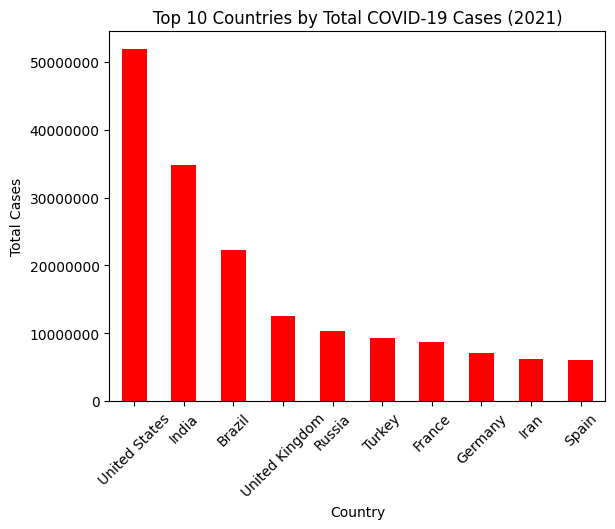

In [19]:
# Using the 2021 data, extract the top 10 worst-affected countries by total cases
top_10_cases_2021 = df_2021.groupby('location')['total_cases'].max().nlargest(10).reset_index()

top_10_cases_2021.plot(x='location', y='total_cases', kind='bar', title='Top 10 Countries by Total COVID-19 Cases (2021)', color='red', legend=False)
plt.xlabel('Country')
plt.ylabel('Total Cases')
plt.ticklabel_format(style='plain', axis='y')
plt.xticks(rotation=45) # Rotate x-axis labels for readability
plt.show()

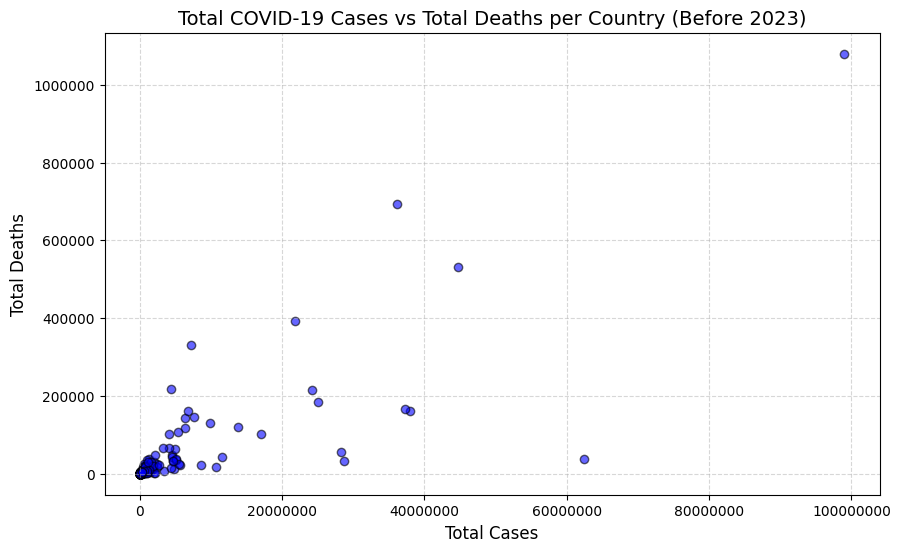

In [20]:
# --- Q9: Scatter Plot - Relationship Between Two Metrics ---
# Group by location (country) and take the maximum cumulative total cases and deaths
country_stats = final_df.groupby('location')[['total_cases', 'total_deaths']].max().reset_index()

# Create the scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(country_stats['total_cases'], country_stats['total_deaths'], alpha=0.6, color='blue', edgecolors='k')

# Add titles and labels
plt.title('Total COVID-19 Cases vs Total Deaths per Country (Before 2023)', fontsize=14)
plt.xlabel('Total Cases', fontsize=12)
plt.ylabel('Total Deaths', fontsize=12)

# Using scientific notation or plain format for axes (optional)
plt.ticklabel_format(style='plain', axis='x')
plt.ticklabel_format(style='plain', axis='y')

plt.grid(True, linestyle='--', alpha=0.5)
plt.show()
